## Model Traning and Evaluation

#### New notebook for ML tasks for data science acellerator to keep notesbooks small and tidy.

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

In [46]:
# read in our processed dataset
df = pd.read_csv('./data/final_df.csv')
print(df.shape)
df.head()

(549900, 11)


,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,gdp_per_cap_o,distw_harmonic,fta_wto,wto_o
0,Aruba,Afghanistan,NaN,14.718799,16.584140,4.621014,10.254067,10.097785,13193.0,0.0,0.0
1,Aruba,Afghanistan,NaN,14.765029,16.698643,4.624306,10.278682,10.140723,13193.0,0.0,0.0
2,Aruba,Afghanistan,NaN,NaN,16.836267,4.628730,10.303087,NaN,13193.0,0.0,0.0
3,Aruba,Afghanistan,NaN,NaN,16.826608,4.633865,10.327175,NaN,13193.0,0.0,0.0
4,Aruba,Afghanistan,NaN,NaN,16.813749,4.642418,10.396903,NaN,13193.0,0.0,0.0


In [47]:
# check size and amount of nulls
print(df.shape)
df.isnull().sum(axis=0)

(549900, 11)


iso3_o                 0
iso3_d                 0
tradeflow_baci    236107
gdp_o              91260
gdp_d              91260
pop_o              62010
pop_d              62010
gdp_per_cap_o      91260
distw_harmonic         0
fta_wto                0
wto_o                  0
dtype: int64

In [48]:
# can we see common trade routes with null traffic
null_countries = df[df['tradeflow_baci'].isnull()]['iso3_o'] + df[df['tradeflow_baci'].isnull()]['iso3_d']
print(f'Number of null routes: {len(null_countries)}')
null_countries.value_counts()

Number of null routes: 236107


ArubaAnguilla                               10
ArubaAlbania                                10
ArubaAndorra                                10
ArubaArmenia                                10
ArubaAmerican Samoa                         10
                                            ..
ZimbabweParaguay                             1
ZimbabweQatar                                1
ZimbabweSeychelles                           1
ZimbabweSaint Vincent and the Grenadines     1
ZimbabweVietnam                              1
Name: count, Length: 32330, dtype: int64

In [49]:
# drop nulls due to sparcity (some countries have too little data to impute/ffill)
df = df.dropna()
df.shape

(271951, 11)

In [50]:
df.head()

,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,gdp_per_cap_o,distw_harmonic,fta_wto,wto_o
7,Aruba,Afghanistan,5.076198,14.944387,16.746889,4.657393,10.499466,10.286994,13184.0,0.0,0.0
8,Aruba,Afghanistan,6.931335,14.979359,16.708835,4.661985,10.523309,10.317374,13184.0,0.0,0.0
9,Aruba,Afghanistan,6.087545,15.012476,16.749338,4.666359,10.546440,10.346116,13184.0,0.0,0.0
10,Aruba,Angola,10.824908,14.718799,18.227956,4.621014,9.880686,10.097785,9574.0,0.0,0.0
11,Aruba,Angola,-1.951928,14.765029,18.461015,4.624306,9.912472,10.140723,9574.0,0.0,0.0


In [51]:
# split into train test
X = df[['gdp_o', 'gdp_d', 'pop_o', 'pop_d', 'gdp_per_cap_o', 'distw_harmonic', 'fta_wto', 'wto_o']]
y = df['tradeflow_baci']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Can we setup a 'simple' baseline model (Linear Regression) for benchmark score

In [52]:
results_models = []
results_rmse = []

In [53]:
# create a simple LR pipeline
lr_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]
)

# simple gridcv params
params = {
    'regressor__positive': [True, False]
}

# run grid search
lr_grid = GridSearchCV(
    estimator= lr_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
lr_grid.fit(X_train, y_train)

# fit predict and measure best model
best_lr_model = lr_grid.best_estimator_
y_pred = best_lr_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
results_models.append('Linear Regression')
results_rmse.append(rmse)

print(f'Best Params for LR model: {lr_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params for LR model: {'regressor__positive': False}
RMSE for LR transformed back: 14.569811032619084


In [54]:
def check_residuals(y_test, y_pred, title_suffix: str = None): 
    """
    Prints a histogram of a regression model's residuals during training.

    Parameters:
    model: The trained regression model.

    Returns:
    A histogram of the residuals.
    """

    # Get the residuals

    
    residuals = y_test - y_pred

    # Histogram of the Residuals
    plt.hist(residuals, bins=30, edgecolor='k')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Residuals (Log){' ' + title_suffix if title_suffix else ''}')
    return plt.show()

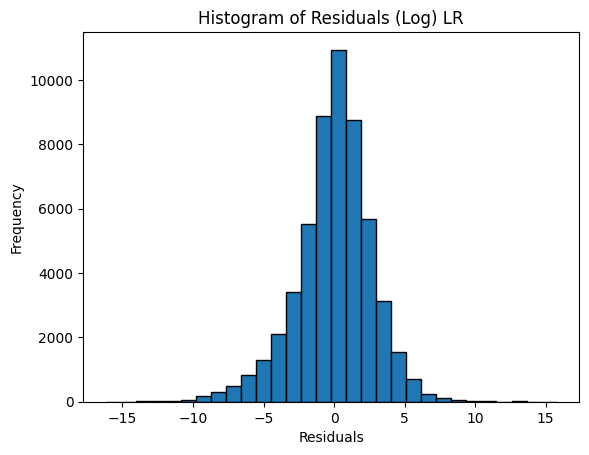

In [55]:
check_residuals(y_test, y_pred, 'LR')

#### Linear Regression Model gives very good accuracy for a simple model. We can start to look at other models to find out if they can improve upon LR's scores

## Random Forrest Regressor


In [56]:
# create a simple LR pipeline
rf_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor())
    ]
)

# simple gridcv params
params = {
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [1, 3],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_leaf_nodes': [None, 3, 5]
}

# run grid search
rf_grid = GridSearchCV(
    estimator= rf_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
rf_grid.fit(X_train, y_train)

# fit predict and measure best model
best_rf_model = rf_grid.best_estimator_
y_pred = best_rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
results_models.append('Random Forest')
results_rmse.append(rmse)

print(f'Best Params for LR model: {rf_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
90 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fi

Best Params for LR model: {'regressor__max_depth': None, 'regressor__max_leaf_nodes': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 3}
RMSE for LR transformed back: 5.402711334724443


## Gradient Boost Regressor

In [57]:
# create a simple LR pipeline
gb_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', GradientBoostingRegressor())
    ]
)

# simple gridcv params
params = {
    'regressor__n_estimators': [20, 50, 100],
    'regressor__min_samples_split': [2, 3],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_leaf_nodes': [None, 3, 5]
}

# run grid search
gb_grid = GridSearchCV(
    estimator= gb_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
gb_grid.fit(X_train, y_train)

# fit predict and measure best model
best_gb_model = gb_grid.best_estimator_
y_pred = best_gb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
results_models.append('Gradient Boost')
results_rmse.append(rmse)

print(f'Best Params for LR model: {gb_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params for LR model: {'regressor__max_leaf_nodes': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 3, 'regressor__n_estimators': 100}
RMSE for LR transformed back: 11.04697997408299


Can we get a plot of the scores for the best gb_grid model?

In [63]:
gb_df = pd.DataFrame(gb_grid.cv_results_)
gb_score = [col for col in gb_df.columns if 'split' in col and 'test_score' in col]
gb_fold_scores = gb_df[gb_score] * -1
best_gb_model_scores = gb_fold_scores.iloc[gb_grid.best_index_]
best_gb_model_scores

split0_test_score    5.767714
split1_test_score    5.746952
split2_test_score    5.791271
split3_test_score    5.856697
split4_test_score    5.701878
Name: 5, dtype: float64

In [61]:
gb_score

['split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score']